#### Fig 3b, c, Supp. Fig 5a, b, c, d

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import scanpy as sc  
import squidpy as sq
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib as mpl 
import pandas as pd
import os

from matplotlib.patches import Rectangle

pd.set_option('display.max_columns',400)
pd.set_option('display.max_categories',40)
# Set general parameters for publication-ready figures
plt.rcParams.update({
    'pdf.fonttype': 42,
    'font.family': 'Arial',  # Set font to Arial
    'font.size': 14,  # Set font size to at least 14
    'axes.labelsize': 14,  # Axes labels size
    'axes.titlesize': 16,  # Title size for axes
    'xtick.labelsize': 14,  # X-tick label size
    'ytick.labelsize': 14,  # Y-tick label size
    'legend.fontsize': 14,  # Legend font size
    'figure.titlesize': 16,  # Figure title size
    'lines.linewidth': 2,  # Line width for clarity
    'axes.linewidth': 1.5,  # Axis line width
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'text.color': 'black',  # Make sure text is black (not grey)
    'axes.labelcolor': 'black',  # Ensure axes labels are black
    'axes.edgecolor': 'black',  # Ensure edge of axes is black
    'axes.facecolor': 'white',
    'xtick.color': 'black',  # Ensure X-tick marks are black
    'ytick.color': 'black',  # Ensure Y-tick marks are black
    'axes.titlepad': 20  # Padding for title
})

In [3]:
save_dir = "figs"
os.makedirs(save_dir, exist_ok=True)

In [4]:
adata_vis = sc.read_h5ad("/Users/jk/Documents/Lab2/visium/python_analysis/local_401/nmf/ann_finest_level/nfact12/h5ad/adata_vis_assigned_cell_types_nfact12_assigned_factors_log_minmax.h5ad")


In [5]:
# Save count data
adata_vis.layers['counts'] = adata_vis.X.copy()

In [6]:
# Normalizing to median total counts
sc.pp.normalize_total(adata_vis)
# Logarithmize the data
sc.pp.log1p(adata_vis)

In [7]:
adata_vis.obs

,in_tissue,array_row,array_col,library_id,alignment,desired_rc,actual_rc,xmin,xmax,ymin,ymax,hpx,vpx,slide,area,date,cytassist_ver,seq_batch,probe_date,probe_lot,probe_group,cond,cond_rep,rep,age,sex,bmi,packyears,FVC,DLCO,6MWD,outcome_long,tte_long,outcome_24m,tte_24m,lobe_lr,lobe,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,n_counts,n_genes,training_batch,AT0,AT1,AT2,AT2 proliferating,Adventitial fibroblasts,Alveolar Mph CCL3+,Alveolar Mph MT-positive,Alveolar Mph proliferating,Alveolar fibroblasts,Alveolar macrophages,B cells,Basal resting,CD4 T cells,CD8 T cells,Classical monocytes,Club (nasal),Club (non-nasal),DC1,DC2,Deuterosomal,EC aerocyte capillary,EC arterial,EC general capillary,EC venous pulmonary,EC venous systemic,Goblet (bronchial),Goblet (nasal),Goblet (subsegmental),Hillock-like,Interstitial Mph perivascular,Ionocyte,Lymphatic EC differentiating,Lymphatic EC mature,Mast cells,Mesothelium,Migratory DCs,Monocyte-derived Mph,Multiciliated (nasal),Multiciliated (non-nasal),Myofibroblasts,NK cells,Neuroendocrine,Non-classical monocytes,Peribronchial fibroblasts,Pericytes,Plasma cells,Plasmacytoid DCs,SM activated stress response,SMG duct,Smooth muscle,Smooth muscle FAM83D+,Subpleural fibroblasts,Suprabasal,T cells proliferating,Unknown,pre-TB secretory,cell_type_assigned,mean_nUMI_factorsfact_0,mean_nUMI_factorsfact_1,mean_nUMI_factorsfact_2,mean_nUMI_factorsfact_3,mean_nUMI_factorsfact_4,mean_nUMI_factorsfact_5,mean_nUMI_factorsfact_6,mean_nUMI_factorsfact_7,mean_nUMI_factorsfact_8,mean_nUMI_factorsfact_9,mean_nUMI_factorsfact_10,mean_nUMI_factorsfact_11,ATI/Endo,Perib. FB,Airway,B,Alv. macro,Alv. FB/immune,Adv. FB,Macro,Immune,SMC,ATII,Plasma,ATI/Endo_log_minmax,Perib. FB_log_minmax,Airway_log_minmax,B_log_minmax,Alv. macro_log_minmax,Alv. FB/immune_log_minmax,Adv. FB_log_minmax,Macro_log_minmax,Immune_log_minmax,SMC_log_minmax,ATII_log_minmax,Plasma_log_minmax,factor_assigned
AACACGTGCATCGCAC-1-18_57617_A1,1.0,76.0,22.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12-06,1.1.5.551,1,2023-09-01,203531,1,IPF,IPF_1,1,77,M,29,10.0,70.0,32.0,413.0,DEAD,23,DEAD,23,left,upper,3961,8.284504,7804.0,8.962520,31.765761,35.212711,39.928242,49.410559,629.0,6.445720,8.059970,0.0,0.0,0.0,0.0,0.0,0.0,7804.0,3961,0,0.000967,0.000081,0.000023,0.000279,0.234594,0.009023,0.003434,0.045472,0.387183,0.001108,3.730742,0.001663,0.065855,0.019768,0.004821,0.127872,0.000417,0.008481,0.040385,0.010641,0.001719,0.002331,0.000529,0.001759,0.004936,0.001933,0.000464,0.042375,0.002770,0.058909,0.003027,0.003101,0.008538,0.003847,0.000322,0.044897,0.017594,0.026567,0.000907,0.003966,0.016523,0.092378,0.008129,0.037726,0.014092,0.968134,0.362111,0.025284,0.008943,0.038652,0.060598,0.231837,0.004889,0.044583,0.001354,0.000324,B cells,0.000000,0.000000,0.000000,3.568719,0.000000,2.327530,0.081827,0.000000,0.780313,0.000000,0.000000,1.475469,0.000000,0.000000,0.000000,3.568719,0.000000,2.327530,0.081827,0.000000,0.780313,0.000000,0.000000,1.475469,0.000000,0.000000,0.000000,0.773084,0.000000,0.717544,0.502845,0.000000,0.620036,0.000000,0.000000,0.740151,B
AACACTTGGCAAGGAA-1-18_57617_A1,1.0,47.0,71.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12-06,1.1.5.551,1,2023-09-01,203531,1,IPF,IPF_1,1,77,M,29,10.0,70.0,32.0,413.0,DEAD,23,DEAD,23,left,upper,3322,8.108623,5412.0,8.596559,15.909091,20.842572,27.475979,40.742794,280.0,5.638355,5.173688,0.0,0.0,0.0,0.0,0.0,0.0,5412.0,3322,0,0.137828,0.802715,0.341800,0.009572,0.139944,0.039461,0.032829,0.186727,0.888112,0.481472,0.039227,0.013804,0.056936,0.042788,0.031012,0.009081,0.043570,0.023910,0.040213,0.001578,1.365678,0.136504,0.618607,0.156473,0.098999,0.008318,0.010266

In [ ]:
moranI = {}
moranI_values = {}
library_id_dict = {}


for cond in ['IPF','NSIP','CHP']:
    library_id_dict[cond] = adata_vis.obs[adata_vis.obs['cond'] == cond]["library_id"].unique().tolist()

    moranI[cond] = pd.DataFrame()
    moranI_values[cond] = {}


    for idx, library_id in enumerate(library_id_dict[cond]):
        adata_vis_sub = adata_vis[adata_vis.obs['library_id']==library_id]



        remove_nan = np.where((adata_vis_sub.X.toarray()[[0], :] == adata_vis_sub.X.toarray()).all(axis=0))
        remove_mt = np.where([gene.startswith('MT-') for gene in adata_vis_sub.var.index])
        remove_indices = np.concatenate((remove_nan, remove_mt), axis=1)
        mask = ~np.isin(np.arange(adata_vis_sub.n_vars), remove_indices)

        adata_vis_sub_filter = adata_vis_sub[:, mask].copy()



        sq.gr.spatial_neighbors(adata_vis_sub_filter, library_key='library_id')
        sq.gr.spatial_autocorr(adata_vis_sub_filter, mode="moran", genes=adata_vis_sub_filter.var_names, corr_method='fdr_bh')

        filtered_genes = adata_vis_sub_filter.uns['moranI'][(adata_vis_sub_filter.uns['moranI']['I'] >= 0.5) ].index.tolist()
        #filtered_genes = adata_vis_sub_filter.uns['moranI'].head(500).index.tolist()
        moranI[cond][library_id] = pd.Series(filtered_genes)

        moranI_values[cond][library_id] = adata_vis_sub_filter.uns['moranI']



In [ ]:
# Save 
np.save("moran.npy", moranI)
np.save("moran_values.npy", moranI_values)

In [ ]:
# moranI = np.load("moran.npy", allow_pickle=True).item()
# moranI_values = np.load("moran_values.npy", allow_pickle=True).item()

In [17]:
moranI_values

{'IPF': {'18_57617_A1':                 I  pval_norm  var_norm  pval_norm_fdr_bh
  IGKC     0.796651   0.000000  0.000108          0.000000
  SFTPC    0.794968   0.000000  0.000108          0.000000
  SFTPB    0.771100   0.000000  0.000108          0.000000
  COL1A1   0.768235   0.000000  0.000108          0.000000
  SCGB1A1  0.750905   0.000000  0.000108          0.000000
  ...           ...        ...       ...               ...
  SNAPC2  -0.027852   0.004047  0.000108          0.019239
  PET100  -0.028631   0.003235  0.000108          0.015976
  SLC35D2 -0.029277   0.002676  0.000108          0.013606
  ASB7    -0.029408   0.002574  0.000108          0.013165
  SNIP1   -0.032269   0.001062  0.000108          0.006154
  
  [16911 rows x 4 columns],
  '20_33940_B2':                 I  pval_norm  var_norm  pval_norm_fdr_bh
  SFTPC    0.780098   0.000000  0.000081          0.000000
  SCGB3A1  0.719734   0.000000  0.000081          0.000000
  SCGB1A1  0.690943   0.000000  0.000081       

In [8]:
from matplotlib import pyplot as plt
import seaborn as sns

In [9]:
from matplotlib.patches import Rectangle

/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_11054/2237284893.py:12: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_vis[adata_vis.obs['library_id']=="20_41615_B1"], ax = ax[i], color=gene, library_id = "20_41615_B1", cmap="Blues", vmin = 'p1', vmax = 'p99', alpha_img=0.4,
/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_11054/2237284893.py:12: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_vis[adata_vis.obs['library_id']=="20_41615_B1"], ax = ax[i], color=gene, library_id = "20_41615_B1", cmap="Blues", vmin = 'p1', vmax = 'p99', alpha_img=0.4,
/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_11054/2237284893.py:12: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_vis[adata_vis.obs['library_id']=="20_41615_B1"], ax = ax[i], color=gene, library_id = "20_41615_B1", cmap="Blues", vmin = 'p1', vmax = 'p99', alpha_img=0.4,
/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh000

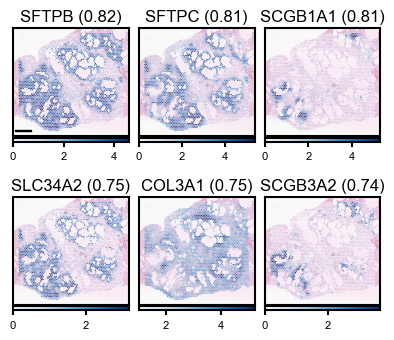

In [ ]:
with mpl.rc_context(
    rc={'xtick.labelsize': 8}
):


    fig, ax = plt.subplots(2,3, figsize = (3.75,3.5))
    ax = ax.flatten()



    for i, gene in enumerate(moranI_values["IPF"]["20_41615_B1"].head(6).index.tolist()):
        sc.pl.spatial(adata_vis[adata_vis.obs['library_id']=="20_41615_B1"], ax = ax[i], color=gene, library_id = "20_41615_B1", cmap="Blues", vmin = 'p20', vmax = 'p99', alpha_img=0.4, 
                    show=False, colorbar_loc = "bottom", title = "")
        ax[i].set_title(f"{gene} ({moranI_values["IPF"]["20_41615_B1"].head(6).iloc[i]["I"]:.2f})", fontsize = 12, pad = 5)

    for axis in ax:
        axis.set_xlabel("")
        axis.set_ylabel("")

    # Add scalebar
    scale_bar_length = adata_vis.uns['spatial']["20_41615_B1"]['scalefactors']['tissue_hires_scalef'] # Length of the scale bar 
                    # with ax1.transAxes, this is the proportion of the total pixel width
                    # ex. 10th of 14000 px, where each px is 0.5 micron
    scale_bar_height = 0.01 # Height of the scale bar

    # Create a rectangle for the scale bar on top of the plot
    scale_bar = Rectangle(
    (0.02,0.05),  # Bottom-left corner of the rectangle (relative coordinates)
    width=scale_bar_length,  # Length of the scale bar
    height=scale_bar_height,  # Height of the scale bar
    transform=ax[0].transAxes,  # Transform relative to the axis
    color='black',  # Color of the scale bar
    linewidth=1  # Thickness of the scale bar
    )

    ax[0].add_patch(scale_bar)



    plt.tight_layout(pad=0, w_pad=0.2, h_pad=0)
    plt.savefig(os.path.join(save_dir,"pl_spatial_svg_ipf_example.pdf"), bbox_inches='tight', transparent = True)
    plt.show()


In [30]:
adata_vis_sub.obs

,in_tissue,array_row,array_col,library_id,alignment,desired_rc,actual_rc,xmin,xmax,ymin,ymax,hpx,vpx,slide,area,date,cytassist_ver,seq_batch,probe_date,probe_lot,probe_group,cond,cond_rep,rep,age,sex,bmi,packyears,FVC,DLCO,6MWD,outcome_long,tte_long,outcome_24m,tte_24m,lobe_lr,lobe,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,n_counts,n_genes,training_batch,AT0,AT1,AT2,AT2 proliferating,Adventitial fibroblasts,Alveolar Mph CCL3+,Alveolar Mph MT-positive,Alveolar Mph proliferating,Alveolar fibroblasts,Alveolar macrophages,B cells,Basal resting,CD4 T cells,CD8 T cells,Classical monocytes,Club (nasal),Club (non-nasal),DC1,DC2,Deuterosomal,EC aerocyte capillary,EC arterial,EC general capillary,EC venous pulmonary,EC venous systemic,Goblet (bronchial),Goblet (nasal),Goblet (subsegmental),Hillock-like,Interstitial Mph perivascular,Ionocyte,Lymphatic EC differentiating,Lymphatic EC mature,Mast cells,Mesothelium,Migratory DCs,Monocyte-derived Mph,Multiciliated (nasal),Multiciliated (non-nasal),Myofibroblasts,NK cells,Neuroendocrine,Non-classical monocytes,Peribronchial fibroblasts,Pericytes,Plasma cells,Plasmacytoid DCs,SM activated stress response,SMG duct,Smooth muscle,Smooth muscle FAM83D+,Subpleural fibroblasts,Suprabasal,T cells proliferating,Unknown,pre-TB secretory,cell_type_assigned,mean_nUMI_factorsfact_0,mean_nUMI_factorsfact_1,mean_nUMI_factorsfact_2,mean_nUMI_factorsfact_3,mean_nUMI_factorsfact_4,mean_nUMI_factorsfact_5,mean_nUMI_factorsfact_6,mean_nUMI_factorsfact_7,mean_nUMI_factorsfact_8,mean_nUMI_factorsfact_9,mean_nUMI_factorsfact_10,mean_nUMI_factorsfact_11,ATI/Endo,Perib. FB,Airway,B,Alv. macro,Alv. FB/immune,Adv. FB,Macro,Immune,SMC,ATII,Plasma,ATI/Endo_log_minmax,Perib. FB_log_minmax,Airway_log_minmax,B_log_minmax,Alv. macro_log_minmax,Alv. FB/immune_log_minmax,Adv. FB_log_minmax,Macro_log_minmax,Immune_log_minmax,SMC_log_minmax,ATII_log_minmax,Plasma_log_minmax,factor_assigned
AACACTTGGCAAGGAA-1-16_39724_B1,1.0,47.0,71.0,16_39724_B1,auto,80,74,0,0,0,0,15806,15893,V44A10-304,D1,2024-12-12,2.0.1.3,5,2024-07-01,203947,2,CHP,CHP_10,10,67,M,32,0.0,55.0,42.0,472.0,ALIVE,60,ALIVE,24,right,lower,2493,7.821643,4243.0,8.353262,19.585199,26.231440,34.291775,49.493283,148.0,5.003946,3.488098,0.0,0.0,0.0,0.0,0.0,0.0,4243.0,2493,0,0.003825,0.097414,0.160124,0.008032,0.021112,0.002792,0.002567,0.019047,0.105757,0.047507,0.005862,0.002506,0.013673,0.010887,0.004698,0.000301,0.000788,0.005166,0.013147,0.000078,0.051953,0.577122,0.023849,0.215488,0.103768,0.000812,0.001037,0.000232,0.008536,0.110755,0.002615,0.267131,0.067828,0.037510,0.025072,0.001064,0.003313,0.000144,0.000105,0.744102,0.007301,0.011848,0.001573,0.020248,0.022591,0.005050,0.001069,0.946306,0.000405,2.700125,0.208952,0.005934,0.003395,0.004464,0.004366,0.000288,Smooth muscle,1.816765,0.00000,0.000000,0.0,0.000000,0.766843,0.000000,0.000000,0.000000,6.865062,0.009318,0.00000,1.816765,0.00000,0.000000,0.0,0.000000,0.766843,0.000000,0.000000,0.000000,6.865062,0.009318,0.00000,0.683012,0.000000,0.000000,0.0,0.000000,0.614868,0.000000,0.000000,0.000000,0.866992,0.238611,0.000000,SMC
AACAGGATTCATAGTT-1-16_39724_B1,1.0,49.0,43.0,16_39724_B1,auto,80,74,0,0,0,0,15806,15893,V44A10-304,D1,2024-12-12,2.0.1.3,5,2024-07-01,203947,2,CHP,CHP_10,10,67,M,32,0.0,55.0,42.0,472.0,ALIVE,60,ALIVE,24,right,lower,1031,6.939254,1381.0,7.231287,20.709631,28.167994,39.826213,61.549602,49.0,3.912023,3.548153,0.0,0.0,0.0,0.0,0.0,0.0,1381.0,1031,0,0.035131,1.015765,1.237214,0.012777,0.001538,0.028290,0.006046,0.019934,0.661802,0.180489,0.012385,0.012988,0.048954,0.051552,0.012401,0.000580,0.001310,0.002867,0.008126,0.000122,0.425678,0.034270,0.288321,0.006154,0.030149,0.001221,0.002003,0.000547,0.

In [18]:
moranI_values

{'IPF': {'18_57617_A1':                 I  pval_norm  var_norm  pval_norm_fdr_bh
  IGKC     0.796651   0.000000  0.000108          0.000000
  SFTPC    0.794968   0.000000  0.000108          0.000000
  SFTPB    0.771100   0.000000  0.000108          0.000000
  COL1A1   0.768235   0.000000  0.000108          0.000000
  SCGB1A1  0.750905   0.000000  0.000108          0.000000
  ...           ...        ...       ...               ...
  SNAPC2  -0.027852   0.004047  0.000108          0.019239
  PET100  -0.028631   0.003235  0.000108          0.015976
  SLC35D2 -0.029277   0.002676  0.000108          0.013606
  ASB7    -0.029408   0.002574  0.000108          0.013165
  SNIP1   -0.032269   0.001062  0.000108          0.006154
  
  [16911 rows x 4 columns],
  '20_33940_B2':                 I  pval_norm  var_norm  pval_norm_fdr_bh
  SFTPC    0.780098   0.000000  0.000081          0.000000
  SCGB3A1  0.719734   0.000000  0.000081          0.000000
  SCGB1A1  0.690943   0.000000  0.000081       

In [46]:
moranI_values["IPF"]["18_57617_A1"]

,I,pval_norm,var_norm,pval_norm_fdr_bh
IGKC,0.796651,0.000000,0.000108,0.000000
SFTPC,0.794968,0.000000,0.000108,0.000000
SFTPB,0.771100,0.000000,0.000108,0.000000
COL1A1,0.768235,0.000000,0.000108,0.000000
SCGB1A1,0.750905,0.000000,0.000108,0.000000
...,...,...,...,...
SNAPC2,-0.027852,0.004047,0.000108,0.019239
PET100,-0.028631,0.003235,0.000108,0.015976
SLC35D2,-0.029277,0.002676,0.000108,0.013606
ASB7,-0.029408,0.002574,0.000108,0.013165


In [11]:
import matplotlib.patches as patches

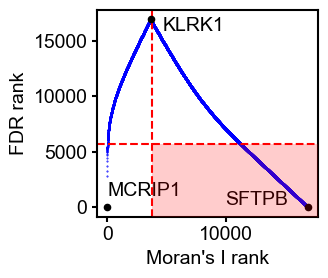

In [604]:
moranI_values_20_41615_B1 = moranI_values['IPF']["20_41615_B1"].copy()

moranI_values_20_41615_B1['I_rank'] = range(len(moranI_values_20_41615_B1 )-1, -1, -1)

moranI_values_20_41615_B1_sorted = moranI_values_20_41615_B1.sort_values(
    by=['pval_norm_fdr_bh', 'pval_norm'],  # second column breaks ties
    ascending=[True, True]
).reset_index(drop=False)




plt.figure(figsize=(3.5,3))
y_positive_idx = moranI_values_20_41615_B1_sorted['pval_norm_fdr_bh'].gt(0.05).idxmax()
x_positive_idx = moranI_values_20_41615_B1_sorted.sort_values(by = "I").reset_index(drop = True)['I'].gt(0).idxmax()

# Highlight first and last point
highlight_points = pd.concat([moranI_values_20_41615_B1_sorted.iloc[[0, -1]],
                              moranI_values_20_41615_B1_sorted.sort_values(by = "I").reset_index(drop = True).iloc[[0]]
])

plt.scatter(
    x=highlight_points['I_rank'], 
    y=highlight_points.index, 
    color='black', s=20, zorder=3, label="Highlighted genes"
)

highlight_points["x_offset"] = [-7000, 1000,0]   # different x shifts
highlight_points["y_offset"] = [200, -1000,1000]   # different y shifts

for _, row in highlight_points.iterrows():
    plt.text(
        row['I_rank'] + row['x_offset'],
        row.name + row['y_offset'],
        row['index'],
        fontsize=14,
        color='black'
    )



plt.scatter(x =  moranI_values_20_41615_B1_sorted['I_rank'],y = moranI_values_20_41615_B1_sorted.index, color='blue', s=0.2)
plt.axhline(y=y_positive_idx, color='red', linestyle='--', linewidth=1.5)
plt.axvline(x=x_positive_idx, color='red', linestyle='--', linewidth=1.5)

# Get current limits (so rectangle spans the visible axes)
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Rectangle: lower right quadrant
rect = patches.Rectangle(
    (x_positive_idx, ylim[0]),              # bottom-left corner
    width=xlim[1] - x_positive_idx,         # span to right edge
    height=y_positive_idx - ylim[0],        # span up to horizontal cutoff
    facecolor='red', alpha=0.2, zorder= 4   # zorder puts it behind points
)
ax.add_patch(rect)

plt.xlabel("Moran's I rank")
plt.ylabel("FDR rank")
plt.tight_layout()
plt.savefig(os.path.join(save_dir,"moranI_rank_scatter_20_41615_B1.pdf"), bbox_inches = 'tight', transparent=True)
plt.show()

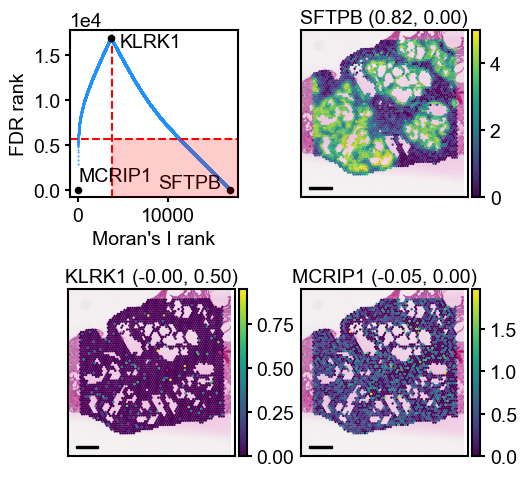

In [19]:
moranI_values_20_41615_B1 = moranI_values['IPF']["20_41615_B1"].copy()

moranI_values_20_41615_B1['I_rank'] = range(len(moranI_values_20_41615_B1 )-1, -1, -1)

moranI_values_20_41615_B1_sorted = moranI_values_20_41615_B1.sort_values(
    by=['pval_norm_fdr_bh', 'pval_norm'],  # second column breaks ties
    ascending=[True, True]
).reset_index(drop=False)

y_positive_idx = moranI_values_20_41615_B1_sorted['pval_norm_fdr_bh'].gt(0.05).idxmax()
x_positive_idx = moranI_values_20_41615_B1_sorted.sort_values(by = "I").reset_index(drop = True)['I'].gt(0).idxmax()

highlight_points = pd.concat([moranI_values_20_41615_B1_sorted.iloc[[0, -1]],
                              moranI_values_20_41615_B1_sorted.sort_values(by = "I").reset_index(drop = True).iloc[[0]]
])
highlight_points["x_offset"] = [-8000, 1000, 0]   # different x shifts
highlight_points["y_offset"] = [200, -1000,1000]   # different y shifts

# Make 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(5.5,5))

# --- (1) Scatter plot in top-left ---
ax = axes[0, 0]

# Scatter of all points
ax.scatter(
    x=moranI_values_20_41615_B1_sorted['I_rank'],
    y=moranI_values_20_41615_B1_sorted.index,
    color='dodgerblue', s=0.2
)

# Highlighted points
ax.scatter(
    x=highlight_points['I_rank'],
    y=highlight_points.index,
    color='black', s=20, zorder=3, label="Highlighted genes"
)

# Annotate with offsets
for _, row in highlight_points.iterrows():
    ax.text(
        row['I_rank'] + row['x_offset'],
        row.name + row['y_offset'],
        row['index'],
        fontsize=14,
        color='black'
    )

# Threshold lines
ax.axhline(y=y_positive_idx, color='red', linestyle='--', linewidth=1.5)
ax.axvline(x=x_positive_idx, color='red', linestyle='--', linewidth=1.5)

# Get current limits (so rectangle spans the visible axes)
#ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Rectangle: lower right quadrant
rect = patches.Rectangle(
    (x_positive_idx, ylim[0]),              # bottom-left corner
    width=xlim[1] - x_positive_idx,         # span to right edge
    height=y_positive_idx - ylim[0],        # span up to horizontal cutoff
    facecolor='red', alpha=0.2, zorder= 4   # zorder puts it behind points
)
ax.add_patch(rect)

ax.set_xlabel("Moran's I rank")
ax.set_ylabel("FDR rank")
ax.set_aspect(1)
from matplotlib.ticker import ScalarFormatter

ax.yaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
#ax.legend()

# --- (2-4) Spatial plots for highlighted genes ---
highlighted_genes = highlight_points['index'].tolist()

# Flatten the axes (skip the first one, since it's scatter)
spatial_axes = [axes[0, 1], axes[1, 0], axes[1, 1]]



for gene, ax in zip(highlighted_genes, spatial_axes):
    sc.pl.spatial(
        adata_vis[adata_vis.obs['library_id']=="20_41615_B1"],   
        library_id = "20_41615_B1",
        color=gene,
        size=1.5,
        ax=ax,
        show=False,
        colorbar_loc = None,
        #title=gene
    )
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xlim(0,2000)
    ax.set_ylim(2000,0)
    
    # Custom width colorbar
    plt.colorbar(
    ax.collections[0],
    ax=ax,
    fraction=0.05,   # changes width
    pad=0.02
    )
    ax.set_title(f"{gene} ({highlight_points.loc[highlight_points['index']==gene, "I"].values[0]:.2f}, {highlight_points.loc[highlight_points['index']==gene, "pval_norm_fdr_bh"].values[0]:.2f})", pad = 5, fontsize = 14)

    # Create a rectangle for the scale bar on top of the plot
    scale_bar = Rectangle(
    (0.05,0.05),  # Bottom-left corner of the rectangle (relative coordinates)
    width=scale_bar_length,  # Length of the scale bar
    height=scale_bar_height,  # Height of the scale bar
    transform=ax.transAxes,  # Transform relative to the axis
    color='black',  # Color of the scale bar
    linewidth=1  # Thickness of the scale bar
    )
    ax.add_patch(scale_bar)


plt.tight_layout(h_pad = 1, w_pad = 0.2)
plt.savefig(os.path.join(save_dir,"moranI_rank_scatter_and_spatial_20_41615_B1.pdf"), bbox_inches = 'tight', transparent=True)
plt.show()


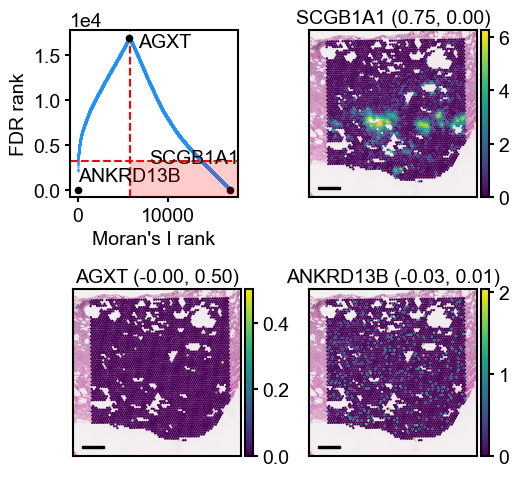

In [21]:
moranI_values_19_18542_A4 = moranI_values['NSIP']["19_18542_A4"].copy()

moranI_values_19_18542_A4['I_rank'] = range(len(moranI_values_19_18542_A4 )-1, -1, -1)

moranI_values_19_18542_A4_sorted = moranI_values_19_18542_A4.sort_values(
    by=['pval_norm_fdr_bh', 'pval_norm'],  # second column breaks ties
    ascending=[True, True]
).reset_index(drop=False)

y_positive_idx = moranI_values_19_18542_A4_sorted['pval_norm_fdr_bh'].gt(0.05).idxmax()
x_positive_idx = moranI_values_19_18542_A4_sorted.sort_values(by = "I").reset_index(drop = True)['I'].gt(0).idxmax()


highlight_points = pd.concat([moranI_values_19_18542_A4_sorted.iloc[[0, -1]],
                              moranI_values_19_18542_A4_sorted.sort_values(by = "I").reset_index(drop = True).iloc[[0]]
])
highlight_points["x_offset"] = [-9000, 1000, 0]   # different x shifts
highlight_points["y_offset"] = [3000, -1000,1000]   # different y shifts

# Make 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(5.5,5))

# --- (1) Scatter plot in top-left ---
ax = axes[0, 0]

# Scatter of all points
ax.scatter(
    x=moranI_values_19_18542_A4_sorted['I_rank'],
    y=moranI_values_19_18542_A4_sorted.index,
    color='dodgerblue', s=0.2
)

# Highlighted points
ax.scatter(
    x=highlight_points['I_rank'],
    y=highlight_points.index,
    color='black', s=20, zorder=3, label="Highlighted genes"
)

# Annotate with offsets
for _, row in highlight_points.iterrows():
    ax.text(
        row['I_rank'] + row['x_offset'],
        row.name + row['y_offset'],
        row['index'],
        fontsize=14,
        color='black'
    )

# Threshold lines
ax.axhline(y=y_positive_idx, color='red', linestyle='--', linewidth=1.5)
ax.axvline(x=x_positive_idx, color='red', linestyle='--', linewidth=1.5)

# Get current limits (so rectangle spans the visible axes)
#ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Rectangle: lower right quadrant
rect = patches.Rectangle(
    (x_positive_idx, ylim[0]),              # bottom-left corner
    width=xlim[1] - x_positive_idx,         # span to right edge
    height=y_positive_idx - ylim[0],        # span up to horizontal cutoff
    facecolor='red', alpha=0.2, zorder= 4   # zorder puts it behind points
)
ax.add_patch(rect)

ax.set_xlabel("Moran's I rank")
ax.set_ylabel("FDR rank")
ax.set_aspect(1)
from matplotlib.ticker import ScalarFormatter

ax.yaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
#ax.legend()

# --- (2-4) Spatial plots for highlighted genes ---
highlighted_genes = highlight_points['index'].tolist()

# Flatten the axes (skip the first one, since it's scatter)
spatial_axes = [axes[0, 1], axes[1, 0], axes[1, 1]]

for gene, ax in zip(highlighted_genes, spatial_axes):
    sc.pl.spatial(
        adata_vis[adata_vis.obs['library_id']=="19_18542_A4"],      
        library_id = "19_18542_A4",
        color=gene,
        size=1.5,
        ax=ax,
        show=False,
        colorbar_loc = None
        #title=gene
    )
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xlim(0,2000)
    ax.set_ylim(2000,0)
        # Custom width colorbar
    plt.colorbar(
    ax.collections[0],
    ax=ax,
    fraction=0.05,   # changes width
    pad=0.02
    )
    ax.set_title(f"{gene} ({highlight_points.loc[highlight_points['index']==gene, "I"].values[0]:.2f}, {highlight_points.loc[highlight_points['index']==gene, "pval_norm_fdr_bh"].values[0]:.2f})", pad = 5, fontsize = 14)

    # Create a rectangle for the scale bar on top of the plot
    scale_bar = Rectangle(
    (0.05,0.05),  # Bottom-left corner of the rectangle (relative coordinates)
    width=scale_bar_length,  # Length of the scale bar
    height=scale_bar_height,  # Height of the scale bar
    transform=ax.transAxes,  # Transform relative to the axis
    color='black',  # Color of the scale bar
    linewidth=1  # Thickness of the scale bar
    )
    ax.add_patch(scale_bar)

plt.tight_layout(h_pad = 1, w_pad = 0.2)
plt.savefig(os.path.join(save_dir,"moranI_rank_scatter_and_spatial_19_18542_A4.pdf"), bbox_inches = 'tight', transparent=True)
plt.show()


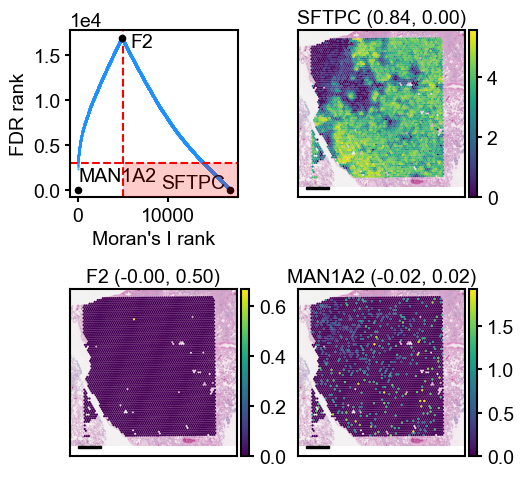

In [22]:
moranI_values_22_18440_A2 = moranI_values['CHP']["22_18440_A2"].copy()

moranI_values_22_18440_A2['I_rank'] = range(len(moranI_values_22_18440_A2 )-1, -1, -1)

moranI_values_22_18440_A2_sorted = moranI_values_22_18440_A2.sort_values(
    by=['pval_norm_fdr_bh', 'pval_norm'],  # second column breaks ties
    ascending=[True, True]
).reset_index(drop=False)

y_positive_idx = moranI_values_22_18440_A2_sorted['pval_norm_fdr_bh'].gt(0.05).idxmax()
x_positive_idx = moranI_values_22_18440_A2_sorted.sort_values(by = "I").reset_index(drop = True)['I'].gt(0).idxmax()

highlight_points = pd.concat([moranI_values_22_18440_A2_sorted.iloc[[0, -1]],
                              moranI_values_22_18440_A2_sorted.sort_values(by = "I").reset_index(drop = True).iloc[[0]]
])
highlight_points["x_offset"] = [-7600, 1000, 0]   # different x shifts
highlight_points["y_offset"] = [200, -1000,1000]   # different y shifts

# Make 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(5.5,5))

# --- (1) Scatter plot in top-left ---
ax = axes[0, 0]

# Scatter of all points
ax.scatter(
    x=moranI_values_22_18440_A2_sorted['I_rank'],
    y=moranI_values_22_18440_A2_sorted.index,
    color='dodgerblue', s=0.2
)

# Highlighted points
ax.scatter(
    x=highlight_points['I_rank'],
    y=highlight_points.index,
    color='black', s=20, zorder=3, label="Highlighted genes"
)

# Annotate with offsets
for _, row in highlight_points.iterrows():
    ax.text(
        row['I_rank'] + row['x_offset'],
        row.name + row['y_offset'],
        row['index'],
        fontsize=14,
        color='black'
    )

# Threshold lines
ax.axhline(y=y_positive_idx, color='red', linestyle='--', linewidth=1.5)
ax.axvline(x=x_positive_idx, color='red', linestyle='--', linewidth=1.5)

# Get current limits (so rectangle spans the visible axes)
#ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Rectangle: lower right quadrant
rect = patches.Rectangle(
    (x_positive_idx, ylim[0]),              # bottom-left corner
    width=xlim[1] - x_positive_idx,         # span to right edge
    height=y_positive_idx - ylim[0],        # span up to horizontal cutoff
    facecolor='red', alpha=0.2, zorder= 4   # zorder puts it behind points
)
ax.add_patch(rect)

ax.set_xlabel("Moran's I rank")
ax.set_ylabel("FDR rank")
ax.set_aspect(1)
from matplotlib.ticker import ScalarFormatter

ax.yaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
#ax.legend()

# --- (2-4) Spatial plots for highlighted genes ---
highlighted_genes = highlight_points['index'].tolist()

# Flatten the axes (skip the first one, since it's scatter)
spatial_axes = [axes[0, 1], axes[1, 0], axes[1, 1]]

for gene, ax in zip(highlighted_genes, spatial_axes):
    sc.pl.spatial(
        adata_vis[adata_vis.obs['library_id']=="22_18440_A2"],       
        library_id = "22_18440_A2",
        color=gene,
        size=1.5,
        ax=ax,
        show=False,
        colorbar_loc = None
        #title=gene
    )
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xlim(0,2000)
    ax.set_ylim(2000,0)

    # Custom width colorbar
    plt.colorbar(
    ax.collections[0],
    ax=ax,
    fraction=0.05,   # changes width
    pad=0.02
    )
    ax.set_title(f"{gene} ({highlight_points.loc[highlight_points['index']==gene, "I"].values[0]:.2f}, {highlight_points.loc[highlight_points['index']==gene, "pval_norm_fdr_bh"].values[0]:.2f})", pad = 5, fontsize = 14)

    # Create a rectangle for the scale bar on top of the plot
    scale_bar = Rectangle(
    (0.05,0.05),  # Bottom-left corner of the rectangle (relative coordinates)
    width=scale_bar_length,  # Length of the scale bar
    height=scale_bar_height,  # Height of the scale bar
    transform=ax.transAxes,  # Transform relative to the axis
    color='black',  # Color of the scale bar
    linewidth=1  # Thickness of the scale bar
    )
    ax.add_patch(scale_bar)
plt.tight_layout(h_pad = 1, w_pad = 0.2)
plt.savefig(os.path.join(save_dir,"moranI_rank_scatter_and_spatial_22_18440_A2.pdf"), bbox_inches = 'tight', transparent=True)
plt.show()


In [31]:
moranI_values['IPF']

{'18_57617_A1':                 I  pval_norm  var_norm  pval_norm_fdr_bh
 IGKC     0.796651   0.000000  0.000108          0.000000
 SFTPC    0.794968   0.000000  0.000108          0.000000
 SFTPB    0.771100   0.000000  0.000108          0.000000
 COL1A1   0.768235   0.000000  0.000108          0.000000
 SCGB1A1  0.750905   0.000000  0.000108          0.000000
 ...           ...        ...       ...               ...
 SNAPC2  -0.027852   0.004047  0.000108          0.019239
 PET100  -0.028631   0.003235  0.000108          0.015976
 SLC35D2 -0.029277   0.002676  0.000108          0.013606
 ASB7    -0.029408   0.002574  0.000108          0.013165
 SNIP1   -0.032269   0.001062  0.000108          0.006154
 
 [16911 rows x 4 columns],
 '20_33940_B2':                 I  pval_norm  var_norm  pval_norm_fdr_bh
 SFTPC    0.780098   0.000000  0.000081          0.000000
 SCGB3A1  0.719734   0.000000  0.000081          0.000000
 SCGB1A1  0.690943   0.000000  0.000081          0.000000
 TMSB4X   0.6

In [32]:
# Create new column "lay_id" from "cond_rep", replacing _ with # to look better
adata_vis.obs['lay_id'] = adata_vis.obs['cond_rep'].astype(str).str.replace("_"," #")

In [ ]:
# So that we can dynamically switch library_id (key) with lay_id (value)
key_map = dict(zip(adata_vis.obs['library_id'].drop_duplicates(), adata_vis.obs['lay_id'].drop_duplicates()))
key_map

{'18_57617_A1': 'IPF #1',
 '20_33940_B2': 'IPF #2',
 '20_24241_A2': 'IPF #3',
 '19_35057_C3': 'NSIP #1',
 '20_17688_B2': 'NSIP #2',
 '20_28197_A1': 'IPF #4',
 '20_22642_A1': 'NSIP #3',
 '20_41501_C1': 'IPF #5',
 '20_33362_C4': 'NSIP #4',
 '20_41847_A1': 'UNC #1',
 '20_41615_B1': 'IPF #6',
 '21_06301_B2': 'IPF #7',
 '21_05738_A1': 'UNC #2',
 '21_57231_A3': 'CHP #1',
 '21_25528_A3': 'UNC #3',
 '22_18446_A1': 'UNC #4',
 '22_18440_A2': 'CHP #2',
 '23_15209_A3': 'CHP #3',
 '22_50637_A1': 'UNC #5',
 '23_50343_B2': 'CHP #4',
 '23_41922_B2': 'CHP #5',
 '24_10794_B1': 'UNC #7',
 '20_12743_C1': 'UNC #8',
 '21_55244_B1': 'UNC #9',
 '23_45450_A3': 'UNC #10',
 '24_23755_A1': 'UNC #11',
 '16_53837_A10': 'UNC #12',
 '19_48719_A1': 'UNC #13',
 '17_35291_B1': 'UNC #14',
 '16_46257_A1': 'UNC #15',
 '18_23779_A2': 'UNC #16',
 '12_39986_A2': 'UNC #17',
 '20_26330_B3': 'NSIP #5',
 '21_24837_A1': 'NSIP #6',
 '06_30914_A1': 'NSIP #7',
 '19_18542_A4': 'NSIP #8',
 '24_27523_C5': 'CHP #6',
 '11_13888_A1': 'CHP 

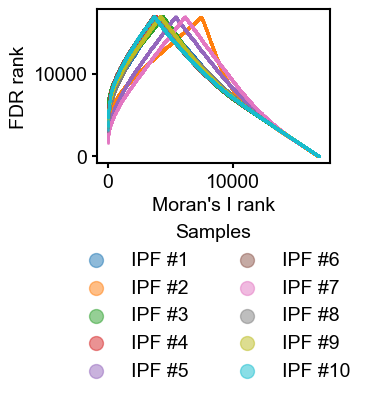

In [43]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

library_ids = list(moranI_values["IPF"].keys())
num_libs = len(library_ids)

# Choose a colormap (tab10, tab20, etc.)
colors = cm.get_cmap("tab10", num_libs)

plt.figure(figsize=(3,2))

for i, lib_id in enumerate(library_ids):
    df = moranI_values["IPF"][lib_id].copy()
    df['I_rank'] = range(len(df)-1, -1, -1)
    
    df_sorted = df.sort_values(
        by=['pval_norm_fdr_bh', 'pval_norm'], ascending=[True, True]
    ).reset_index(drop=False)
    
   
    
    # Plot all points colored by library
    plt.scatter(df_sorted['I_rank'], df_sorted.index,
                color=colors(i), s=1, alpha=0.5, label=key_map.get(lib_id)) # dynamically change lib_id by finding its key in key_map
    

plt.xlabel("Moran's I rank")
plt.ylabel("FDR rank")
plt.legend(title="Samples", frameon=False,
           ncols = 2, markerscale=10, loc = "center", bbox_to_anchor = (0.5,-0.9)
           )
plt.tight_layout()
plt.savefig(os.path.join(save_dir,"moranI_rank_scatter_IPF_overlay_colored.pdf"),
            bbox_inches='tight', transparent=True)
plt.show()


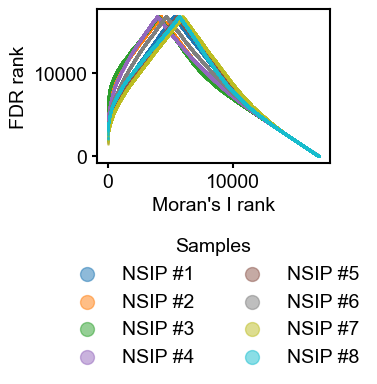

In [47]:


library_ids = list(moranI_values["NSIP"].keys())
num_libs = len(library_ids)

# Choose a colormap (tab10, tab20, etc.)
colors = cm.get_cmap("tab10", num_libs)

plt.figure(figsize=(3,2))

for i, lib_id in enumerate(library_ids):
    df = moranI_values["NSIP"][lib_id].copy()
    df['I_rank'] = range(len(df)-1, -1, -1)
    
    df_sorted = df.sort_values(
        by=['pval_norm_fdr_bh', 'pval_norm'], ascending=[True, True]
    ).reset_index(drop=False)
    
   
    
    # Plot all points colored by library
    plt.scatter(df_sorted['I_rank'], df_sorted.index,
                color=colors(i), s=1, alpha=0.5, label=key_map.get(lib_id))
    

plt.xlabel("Moran's I rank")
plt.ylabel("FDR rank")
plt.legend(title="Samples", frameon=False,
           ncols = 2, markerscale=10, loc = "center", bbox_to_anchor = (0.5,-0.9)
           )
plt.tight_layout()
plt.savefig(os.path.join(save_dir,"moranI_rank_scatter_NSIP_overlay_colored.pdf"),
            bbox_inches='tight', transparent=True)
plt.show()


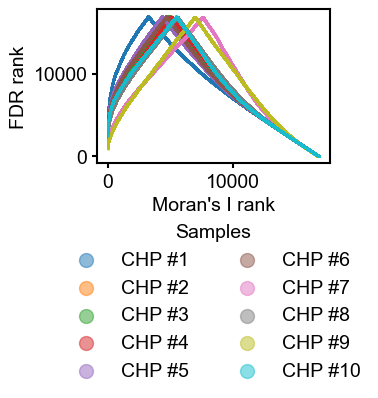

In [44]:


library_ids = list(moranI_values["CHP"].keys())
num_libs = len(library_ids)

# Choose a colormap (tab10, tab20, etc.)
colors = cm.get_cmap("tab10", num_libs)

plt.figure(figsize=(3,2))

for i, lib_id in enumerate(library_ids):
    df = moranI_values["CHP"][lib_id].copy()
    df['I_rank'] = range(len(df)-1, -1, -1)
    
    df_sorted = df.sort_values(
        by=['pval_norm_fdr_bh', 'pval_norm'], ascending=[True, True]
    ).reset_index(drop=False)
    
   
    
    # Plot all points colored by library
    plt.scatter(df_sorted['I_rank'], df_sorted.index,
                color=colors(i), s=1, alpha=0.5, label=key_map.get(lib_id))
    

plt.xlabel("Moran's I rank")
plt.ylabel("FDR rank")
plt.legend(title="Samples", frameon=False,
           ncols = 2, markerscale=10, loc = "center", bbox_to_anchor = (0.5,-0.9)
           )
plt.tight_layout()
plt.savefig(os.path.join(save_dir,"moranI_rank_scatter_CHP_overlay_colored.pdf"),
            bbox_inches='tight', transparent=True)
plt.show()


/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_2376/1346087558.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


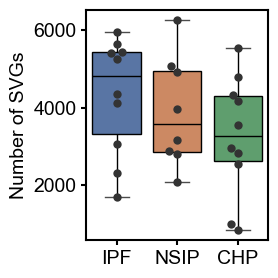

In [493]:
boxprops=dict(edgecolor="black")
whiskerprops=dict(color="black")
capprops=dict(color='black')
medianprops=dict(color='black')
flierprops = dict(marker='x', markerfacecolor='lightgrey', markersize=1,
                  linestyle='none')
# Collect counts for all conditions
import seaborn as sns
records = []
for condition, libs in moranI_values.items():      # e.g. "CHP", "IPF", "NSIP"
    for lib_id, df in libs.items():                # iterate through libraries
        # count SVGs (I > 0 and adj p < 0.05)
        svg_count = df[(df["I"] > 0) & (df['pval_norm_fdr_bh'] < 0.05)].shape[0]
        records.append({"Condition": condition, "Library": lib_id, "SVGs": svg_count})

# Convert to DataFrame
df_counts = pd.DataFrame(records)

# Make a boxplot across conditions
plt.figure(figsize=(3, 3))

sns.boxplot(
    data=df_counts, x="Condition", y="SVGs",
    #order=order,
    palette="deep",
    flierprops=flierprops, boxprops=boxprops, whiskerprops=whiskerprops, medianprops=medianprops
)

sns.swarmplot(
    data=df_counts, x="Condition", y="SVGs",
    #order=order,
    color=".2",          # dark gray points
    size=6,
    zorder=2             # make sure points appear above the box
)
plt.ylabel("Number of SVGs")
plt.xlabel("")
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "SVG_counts_boxplot.pdf"),
            bbox_inches='tight', transparent=True)
plt.show()

/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_2376/1220871375.py:30: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


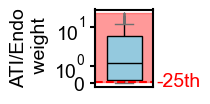

In [573]:
values = adata_vis[adata_vis.obs['library_id']=="20_41615_B1"].obs['ATI/Endo']

plt.figure(figsize=(0.75, 1))
sns.boxplot(y=values, color = "skyblue", flierprops=flierprops, boxprops=boxprops, whiskerprops=whiskerprops, medianprops=medianprops, width=0.6)
#sns.swarmplot(y=values, color="black", size=6)

# Compute 25th percentile
p25 = np.percentile(values, 20)

# Draw horizontal dotted line
plt.axhline(y=p25, color='red', linestyle='--', linewidth=1.5, label='25th percentile')
plt.yscale("symlog")
# Shade area above 25th percentile
plt.axhspan(p25, values.max(), color='red', alpha=0.4) 



# Add text label to the right of the line
xmax = plt.gca().get_xlim()[1]
plt.text(
    xmax + 0.05, p25 + 0.05, "-25th",
    va="center", ha="left", color="red", fontsize=14
)
#plt.title("20_41615_B1", pad = 10, fontsize = 14)
plt.ylabel("ATI/Endo\n weight")
#plt.ylim(0, values.max())
#plt.yscale('log')
plt.xticks([])
#plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "20_41615_B1_ATI_Endo_weight_dist_boxplot.pdf"),
            bbox_inches='tight', transparent=True)
plt.show()
